# 53 Boost Sale Optuna — XGBoost optimizado con Optuna para venta

Versión de `53_boost_sale.ipynb` que sustituye los hiperparámetros hardcodeados por búsqueda con **Optuna**:

- **Dataset**: `final_sale_idealistaAPI.csv`
- **Todas las features**: BASE_FEATURES + todos los `municipio_*` OHE del gold
- Eliminación de outliers con **IQR×1.5** sobre `log_precio` + suelo de `precio_m2`
- **Optuna** (100 trials, CV-RMSE 5-fold) para búsqueda de hiperparámetros

Los params exportables se muestran en la sección 9 para copiar a `55_sale_rent_models`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ──────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
MIN_MUNI_OBS      = 10
OPTUNA_TRIALS     = 100

# ── Rutas ──────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SALE_PATH    = PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Dataset sale: {SALE_PATH}")

/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Proyecto: /Users/sitomachucas/Documents/BezanillaSL
Dataset sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv


## 1. Carga y exploración inicial

Filas totales: 2532
Columnas: 70

Nulos por columna:
planta          1191
distrito         690
subtipologia    1569
dtype: int64


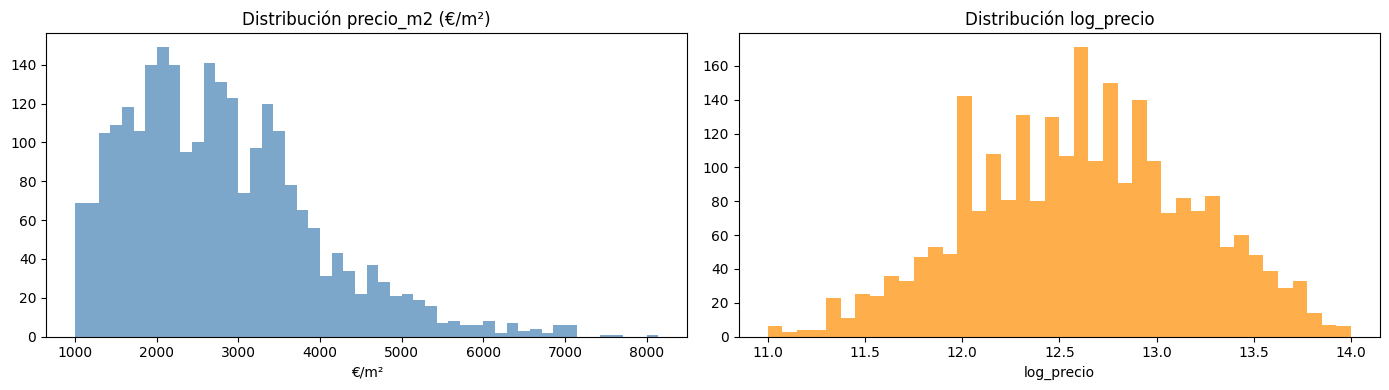


Estadísticas log_precio:
count    2532.0000
mean       12.6092
std         0.5687
min        11.0004
25%        12.1846
50%        12.6082
75%        13.0148
max        13.9978
Name: log_precio, dtype: float64


In [2]:
df_raw = pd.read_csv(SALE_PATH)
print(f"Filas totales: {len(df_raw)}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nNulos por columna:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_raw["precio_m2"].dropna(), bins=50, color="steelblue", alpha=0.7)
axes[0].set_title("Distribución precio_m2 (€/m²)")
axes[0].set_xlabel("€/m²")
axes[1].hist(df_raw[TARGET_COL].dropna(), bins=40, color="darkorange", alpha=0.7)
axes[1].set_title(f"Distribución {TARGET_COL}")
axes[1].set_xlabel(TARGET_COL)
plt.tight_layout()
plt.show()

print(f"\nEstadísticas {TARGET_COL}:")
print(df_raw[TARGET_COL].describe().round(4))

## 2. Datos de entrenamiento

Los outliers (IQR×1.5 sobre log_precio, suelo precio_m2 < 1 000 €/m²) se eliminan
**upstream** en `idealistaAPI_processing_outliers.ipynb` antes de construir el gold.
Aquí solo se descartan filas sin target válido.

In [3]:
df = df_raw[df_raw[TARGET_COL].notna()].copy()
print(f"Filas para modelar: {len(df)}")
print("(outliers eliminados upstream en idealistaAPI_processing_outliers)")


Filas para modelar: 2532
(outliers eliminados upstream en idealistaAPI_processing_outliers)


## 3. Features y funciones auxiliares

In [4]:
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "planta_num",
    "es_exterior_piso",
    "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    # "ratio_dormitorios_superficie",
    # "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]


def build_X(df: pd.DataFrame) -> tuple:
    df2 = df.copy()
    base = [f for f in BASE_FEATURES if f in df2.columns]
    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []
    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()

    # Piso-only features → NaN para unifamiliares; XGBoost aprende a enrutarlas.
    # Evita la ambigüedad: 0 significaba "piso sin X" O "unifamiliar".
    _PISO_ONLY = {"tiene_ascensor_piso", "es_exterior_piso",
                  "planta_num", "interaccion_planta_sin_ascensor_piso"}
    if "tipologia_unificada_unifamiliar" in df2.columns:
        _uni = df2["tipologia_unificada_unifamiliar"] == 1
        for _f in _PISO_ONLY:
            if _f in X.columns:
                X.loc[_uni, _f] = np.nan

    _piso_cols  = [f for f in all_feats if f in _PISO_ONLY]
    _other_cols = [f for f in all_feats if f not in _PISO_ONLY]
    _imp = SimpleImputer(strategy="median")
    _X_other = pd.DataFrame(_imp.fit_transform(X[_other_cols]),
                             columns=_other_cols, index=X.index)
    X = pd.concat([_X_other, X[_piso_cols]], axis=1)[all_feats]
    return X, all_feats


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel(f"Real ({TARGET_COL})")
    ax.set_ylabel(f"Predicho ({TARGET_COL})")
    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")
    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances, feature_names, title, top_n=20):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


# ── Fix 2: precio_m2_municipio_media solo desde train (evita leakage) ─────────
_mun_oh = [c for c in df.columns if c.startswith("municipio_")]
df["_mun"] = df[_mun_oh].idxmax(axis=1).str.replace("municipio_", "")
_idx_tr, _idx_te = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_mun_means = df.loc[_idx_tr].groupby("_mun")["precio_m2"].mean()
_global_mean = float(df.loc[_idx_tr, "precio_m2"].mean())
df["precio_m2_municipio_media"] = (
    df["_mun"].map(_mun_means).fillna(_global_mean)
)
df = df.drop(columns=["_mun"])

X, feats = build_X(df)
y = df[TARGET_COL].values
print(f"Features ({len(feats)}):")
print(feats)

Features (47):
['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos', 'municipio_Polanco', 'municipio_Ribamontan al Mar', 'municipio_Ribamontan al Monte', 'municipio_Santa Cruz de Bezana', 'municipio_Santander', 'municipio_Santoña', 'mun

In [5]:
# ── Investigación: ¿por qué numero_banos puede salir como top feature? ─────────
print("Correlaciones con log_precio:")
for col in ["numero_banos", "superficie_construida_m2", "numero_dormitorios", "precio_m2_municipio_media"]:
    if col in df.columns:
        print(f"  {col}: {df[col].corr(df[TARGET_COL]):.4f}")

print(f"\nnumero_banos distribución (tras limpieza):")
print(df["numero_banos"].value_counts().sort_index().to_string())
print(f"\nResumen: numero_banos tiene la correlación lineal más alta con log_precio "
      f"({df['numero_banos'].corr(df[TARGET_COL]):.4f}) — su importancia es legítima.")

Correlaciones con log_precio:
  numero_banos: 0.6241
  superficie_construida_m2: 0.6966
  numero_dormitorios: 0.5476
  precio_m2_municipio_media: 0.1250

numero_banos distribución (tras limpieza):
numero_banos
0       18
1      896
2     1006
3      417
4      131
5       43
6       16
7        3
10       1
11       1

Resumen: numero_banos tiene la correlación lineal más alta con log_precio (0.6241) — su importancia es legítima.


## 4. Split train / test

In [6]:
# Split consistente con los índices usados para calcular precio_m2_municipio_media
X_df    = pd.DataFrame(X, index=df.index, columns=feats)
X_train = X_df.loc[_idx_tr].values
X_test  = X_df.loc[_idx_te].values
y_train = df.loc[_idx_tr, TARGET_COL].values
y_test  = df.loc[_idx_te, TARGET_COL].values
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {X_df.shape[1]}")

Train: 2025 | Test: 507 | Features: 47


## 5. Búsqueda de hiperparámetros con Optuna

Objetivo: minimizar CV-RMSE (5-fold) sobre el conjunto de train.  
El test **no se toca** durante la búsqueda.

In [7]:
def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 200, 1000, step=50),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 15),
        reg_lambda        = trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        gamma             = trial.suggest_float("gamma", 0.0, 5.0),
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbosity         = 0,
    )
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv = cross_val_score(
        XGBRegressor(**params), X_train, y_train,
        cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return float(-cv.mean())


study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nMejor CV-RMSE: {study.best_value:.5f}")
print("Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 68. Best value: 0.234449: 100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


Mejor CV-RMSE: 0.23445
Mejores hiperparámetros:
  n_estimators: 900
  max_depth: 6
  learning_rate: 0.013693938318582058
  subsample: 0.6250722201248828
  colsample_bytree: 0.7441334899841819
  min_child_weight: 1
  reg_lambda: 0.8039267216172503
  reg_alpha: 0.22243915579180695
  gamma: 0.0010446114637011929


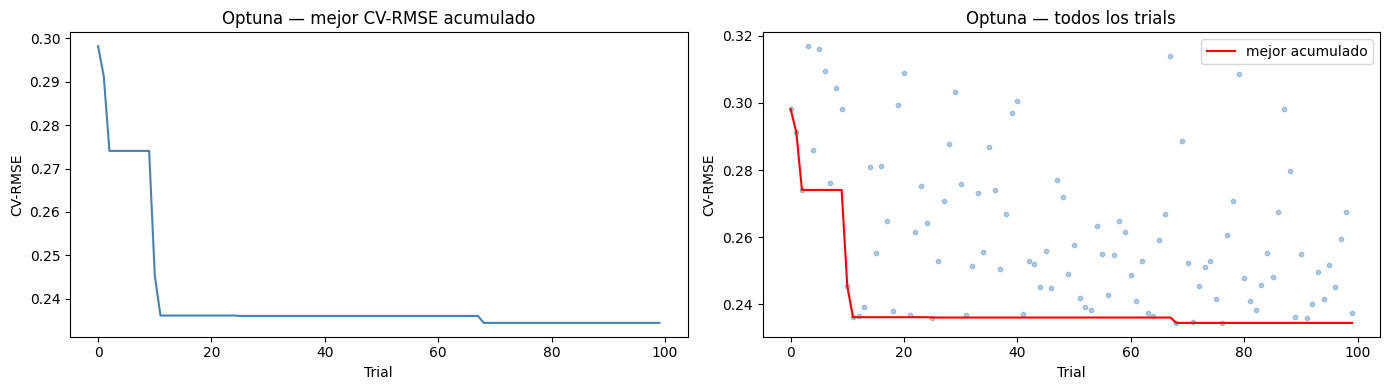

In [8]:
# Curva de convergencia de Optuna
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_so_far, color="steelblue")
axes[0].set_title("Optuna — mejor CV-RMSE acumulado")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("CV-RMSE")

axes[1].scatter(range(len(trial_values)), trial_values, alpha=0.4, s=10, color="steelblue")
axes[1].plot(best_so_far, color="red", linewidth=1.5, label="mejor acumulado")
axes[1].set_title("Optuna — todos los trials")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("CV-RMSE")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Modelo final con mejores hiperparámetros

In [9]:
BEST_PARAMS = {**study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0}

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train, y_train)

# CV final sobre train
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = float(-cross_val_score(
    XGBRegressor(**BEST_PARAMS), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

m_train = get_metrics(y_train, model.predict(X_train))
m_test  = get_metrics(y_test,  model.predict(X_test))

summary = pd.concat([
    m_train.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None],
                  "RMSE": [round(cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_test.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]

print(f"\n{summary.to_string(index=False)}")

delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
print(f"\nSobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R²: {delta_r2:.4f}")


split     MSE    RMSE     MAE      R2    MAPE
train 0.01148 0.10717 0.07894 0.96436 0.00628
   CV     NaN 0.23445     NaN     NaN     NaN
 test 0.05522 0.23498 0.16749 0.83130 0.01340

Sobreajuste → ratio RMSE test/train: 2.1926 | delta R²: 0.1331


## 7. Diagnósticos

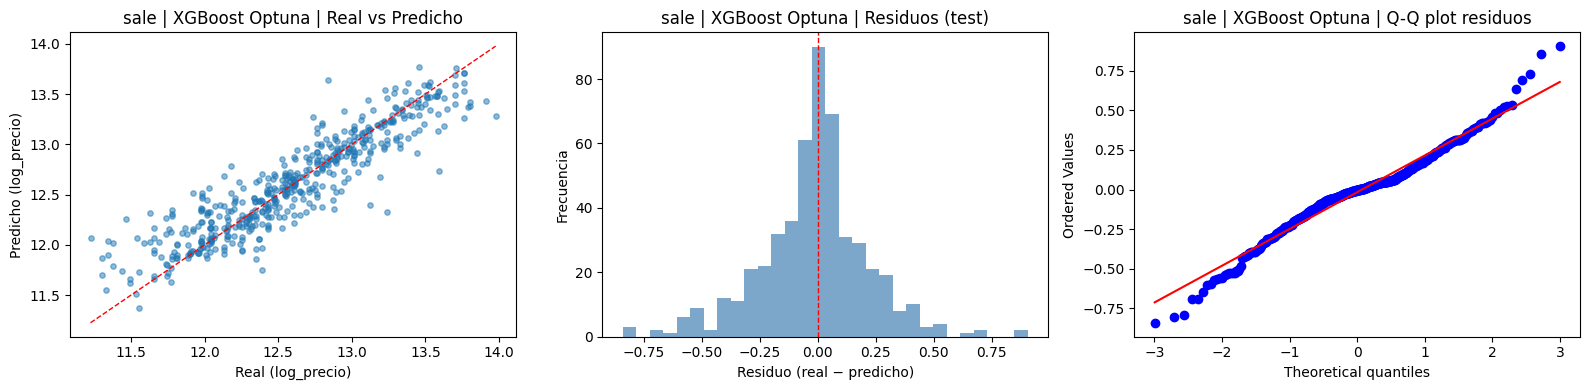

In [10]:
plot_diagnostics(y_test, model.predict(X_test), "sale | XGBoost Optuna")

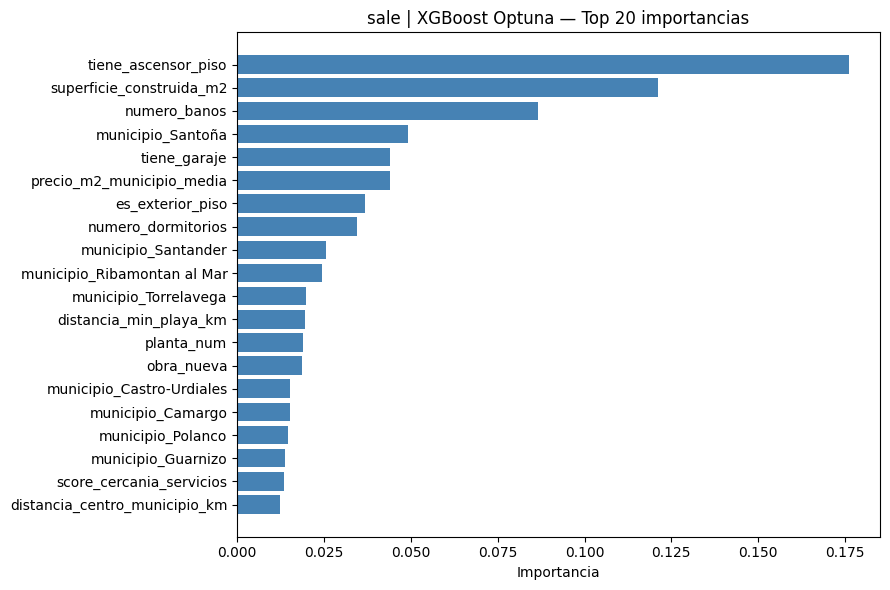

                      feature  importance
          tiene_ascensor_piso    0.176258
     superficie_construida_m2    0.121290
                 numero_banos    0.086694
            municipio_Santoña    0.049035
                 tiene_garaje    0.043889
    precio_m2_municipio_media    0.043865
             es_exterior_piso    0.036774
           numero_dormitorios    0.034529
          municipio_Santander    0.025505
  municipio_Ribamontan al Mar    0.024410
        municipio_Torrelavega    0.019664
       distancia_min_playa_km    0.019631
                   planta_num    0.019054
                   obra_nueva    0.018790
    municipio_Castro-Urdiales    0.015290
            municipio_Camargo    0.015135
            municipio_Polanco    0.014522
           municipio_Guarnizo    0.013865
     score_cercania_servicios    0.013383
distancia_centro_municipio_km    0.012269


In [11]:
fi = plot_feature_importance(
    model.feature_importances_, feats,
    "sale | XGBoost Optuna — Top 20 importancias"
)
print(fi.to_string(index=False))

## 8. Comparativa con hiperparámetros anteriores (hardcodeados)

Evaluamos los hiperparámetros hardcodeados de `53_boost_sale` frente a los encontrados por Optuna,
usando el mismo train/test split para comparación justa.

In [12]:
HARDCODED_PARAMS = dict(
    n_estimators     = 400,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_lambda       = 3,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbosity        = 0,
)

model_hc = XGBRegressor(**HARDCODED_PARAMS)
model_hc.fit(X_train, y_train)

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rmse_hc = float(-cross_val_score(
    XGBRegressor(**HARDCODED_PARAMS), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

m_test_hc = get_metrics(y_test, model_hc.predict(X_test))

print("Comparativa: hardcodeados vs Optuna")
print(f"{'':30s} {'Hardcoded':>12s} {'Optuna':>12s}")
print(f"{'CV-RMSE (train)':30s} {cv_rmse_hc:>12.5f} {cv_rmse:>12.5f}")
print(f"{'Test RMSE':30s} {float(m_test_hc['RMSE'].iloc[0]):>12.5f} {float(m_test['RMSE'].iloc[0]):>12.5f}")
print(f"{'Test R²':30s} {float(m_test_hc['R2'].iloc[0]):>12.5f} {float(m_test['R2'].iloc[0]):>12.5f}")
print(f"{'Test MAE':30s} {float(m_test_hc['MAE'].iloc[0]):>12.5f} {float(m_test['MAE'].iloc[0]):>12.5f}")

Comparativa: hardcodeados vs Optuna
                                  Hardcoded       Optuna
CV-RMSE (train)                     0.24015      0.23445
Test RMSE                           0.24837      0.23498
Test R²                             0.81152      0.83130
Test MAE                            0.18046      0.16749


## 9. Resumen y parámetros exportables

In [13]:
print("=" * 80)
print("RESUMEN FINAL — XGBoost Sale (Optuna)")
print("=" * 80)
print(f"  Target             : {TARGET_COL}")
print(f"  Filas tras limpieza: {len(df)}")
print(f"  Features           : {len(feats)}")
print(f"  Optuna trials      : {OPTUNA_TRIALS}")
print(f"  Mejor trial        : #{study.best_trial.number}")
print(f"  CV-RMSE (train)    : {cv_rmse:.5f}")
print(f"  Test RMSE          : {float(m_test['RMSE'].iloc[0]):.5f}")
print(f"  Test R²            : {float(m_test['R2'].iloc[0]):.5f}")
print()
params_export = {k: v for k, v in BEST_PARAMS.items()
                 if k not in ("random_state", "n_jobs", "verbosity")}
print("Hiperparámetros óptimos (para copiar a 55_sale_rent_models):")
print(f"  XGB_PARAMS_SALE   = {params_export}")
print(f"  XGB_FEATURES_SALE = {feats}")

RESUMEN FINAL — XGBoost Sale (Optuna)
  Target             : log_precio
  Filas tras limpieza: 2532
  Features           : 47
  Optuna trials      : 100
  Mejor trial        : #68
  CV-RMSE (train)    : 0.23445
  Test RMSE          : 0.23498
  Test R²            : 0.83130

Hiperparámetros óptimos (para copiar a 55_sale_rent_models):
  XGB_PARAMS_SALE   = {'n_estimators': 900, 'max_depth': 6, 'learning_rate': 0.013693938318582058, 'subsample': 0.6250722201248828, 'colsample_bytree': 0.7441334899841819, 'min_child_weight': 1, 'reg_lambda': 0.8039267216172503, 'reg_alpha': 0.22243915579180695, 'gamma': 0.0010446114637011929}
  XGB_FEATURES_SALE = ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'es_exterior_piso', 'tiene_ascensor_piso', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'scor

## 10. Exportar parámetros

Guarda todos los resultados en `data/model_results/params_sale.json` para que `55_sale_rent_models` los lea automáticamente.

In [14]:
import json as _json, datetime as _dt

# ── Exportar resultados a data/model_results/params_sale.json ─────────────────
_PARAMS_DIR = PROJECT_ROOT / "data" / "model_results"
_PARAMS_DIR.mkdir(parents=True, exist_ok=True)

_params = {
    "notebook": "53_boost_sale_optuna",
    "generated_at": _dt.datetime.now().isoformat(timespec="seconds"),
    "target_col": TARGET_COL,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "min_muni_obs": MIN_MUNI_OBS,
    "optuna_trials": OPTUNA_TRIALS,
    "base_features": BASE_FEATURES,
    "xgb_params": {k: v for k, v in BEST_PARAMS.items()
                   if k not in ("random_state", "n_jobs", "verbosity")},
    "optuna_best_trial": int(study.best_trial.number),
    "optuna_cv_rmse": round(cv_rmse, 5),
    "test_rmse": round(float(m_test["RMSE"].iloc[0]), 5),
    "test_r2": round(float(m_test["R2"].iloc[0]), 5),
    "mun_means_sale": _mun_means.to_dict(),
    "mun_global_mean_sale": _global_mean,
}

_out = _PARAMS_DIR / "params_sale.json"
with open(_out, "w", encoding="utf-8") as _f:
    _json.dump(_params, _f, ensure_ascii=False, indent=2)

print(f"\u2713 Exportado \u2192 {_out}")
print(f"  Trial #{_params['optuna_best_trial']}  |  CV-RMSE: {_params['optuna_cv_rmse']}  |  Test R\u00b2: {_params['test_r2']}")
print(f"  Features ({len(BASE_FEATURES)}): {BASE_FEATURES[:3]} ... {BASE_FEATURES[-3:]}")


✓ Exportado → /Users/sitomachucas/Documents/BezanillaSL/data/model_results/params_sale.json
  Trial #68  |  CV-RMSE: 0.23445  |  Test R²: 0.8313
  Features (17): ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos'] ... ['score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar']
